# Algoritmo Apriori - Reglas de Asociación

**Objetivo**: Identificar conjuntos de ítems que aparecen frecuentemente juntos en transacciones y generar reglas de asociación.

**Dataset**: Market Basket Optimization (transacciones de un supermercado)

**Bibliotecas**: pandas, apyori

**Descripcion**: El algoritmo Apriori es un método de minería de datos diseñado para el descubrimiento de itemsets frecuentes y reglas de asociación en bases de datos relacionales. Fue propuesto por Agrawal y Srikant en 1994 y se ha convertido en uno de los algoritmos fundamentales en el área de minería de reglas de asociación.

El algoritmo utiliza un enfoque "bottom-up" (ascendente): comienza identificando los items individuales frecuentes en la base de datos y los extiende progresivamente a itemsets de mayor tamaño, siempre que estos aparezcan con la frecuencia suficiente. La búsqueda es de tipo breadth-first (amplitud) y se organiza por niveles (level-wise).

El corazón del algoritmo es la propiedad Apriori: todos los subconjuntos no vacíos de un itemset frecuente deben ser también frecuentes. Esta propiedad permite podar el espacio de búsqueda, descartando candidatos que contengan subconjuntos infrecuentes sin necesidad de evaluarlos.


In [1]:
# Instalar la librería apyori para el algoritmo Apriori
!pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=1dd2207280aa80deeba97132eb74a199fd592219b743e5c938a5e6c388420a2a
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [2]:
import pandas as pd
import numpy as np
from apyori import apriori
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [3]:
# Cargar el dataset (transacciones de Market Basket Optimization)
# Si tienes el archivo en tu Drive, usa la ruta correspondiente
# Para este ejemplo, usaremos datos simulados

# Datos de ejemplo: transacciones de un supermercado
transactions = [
    ['leche', 'pan', 'huevos'],
    ['cerveza', 'pan', 'leche'],
    ['leche', 'huevos', 'mantequilla'],
    ['cerveza', 'huevos'],
    ['leche', 'pan', 'huevos', 'mantequilla'],
    ['cerveza', 'pan', 'mantequilla'],
    ['leche', 'pan'],
    ['cerveza', 'leche', 'huevos', 'pan'],
    ['leche', 'huevos', 'pan'],
    ['cerveza', 'mantequilla']
]

print(f"📊 Número de transacciones: {len(transactions)}")
print("\n📋 Primeras 5 transacciones:")
for i in range(5):
    print(f"  Transacción {i+1}: {transactions[i]}")

📊 Número de transacciones: 10

📋 Primeras 5 transacciones:
  Transacción 1: ['leche', 'pan', 'huevos']
  Transacción 2: ['cerveza', 'pan', 'leche']
  Transacción 3: ['leche', 'huevos', 'mantequilla']
  Transacción 4: ['cerveza', 'huevos']
  Transacción 5: ['leche', 'pan', 'huevos', 'mantequilla']


In [4]:
# Aplicar el algoritmo Apriori
# min_support: soporte mínimo (fracción de transacciones)
# min_confidence: confianza mínima
# min_lift: lift mínimo (debe ser > 1 para reglas interesantes)
# min_length: longitud mínima de la regla

min_support = 0.3      # 30% de las transacciones
min_confidence = 0.6   # 60% de confianza
min_lift = 1.0         # Lift > 1 indica correlación positiva

rules = apriori(
    transactions=transactions,
    min_support=min_support,
    min_confidence=min_confidence,
    min_lift=min_lift,
    min_length=2
)

# Convertir los resultados a lista
results = list(rules)

print(f"🔍 Reglas encontradas: {len(results)}")
print(f"📌 Parámetros utilizados:")
print(f"   - Soporte mínimo: {min_support}")
print(f"   - Confianza mínima: {min_confidence}")
print(f"   - Lift mínimo: {min_lift}")

🔍 Reglas encontradas: 6
📌 Parámetros utilizados:
   - Soporte mínimo: 0.3
   - Confianza mínima: 0.6
   - Lift mínimo: 1.0


In [5]:
# Función para mostrar los resultados de forma organizada
def inspect_results(results):
    """
    Muestra los conjuntos de ítems frecuentes y las reglas de asociación
    """
    print("\n" + "="*60)
    print("📈 CONJUNTOS DE ÍTEMS FRECUENTES")
    print("="*60)

    for item in results:
        # itemsets frecuentes
        for ordered_stat in item.ordered_statistics:
            antecedent = list(ordered_stat.items_base)
            consequent = list(ordered_stat.items_add)
            support = item.support
            confidence = ordered_stat.confidence
            lift = ordered_stat.lift

            print(f"\n🔹 Regla: {antecedent} → {consequent}")
            print(f"   Soporte: {support:.2f} ({support*100:.1f}%)")
            print(f"   Confianza: {confidence:.2f} ({confidence*100:.1f}%)")
            print(f"   Lift: {lift:.2f}")

    # Resumen de itemsets frecuentes
    print("\n" + "="*60)
    print("📊 RESUMEN DE ITEMSETS FRECUENTES")
    print("="*60)

    for i, item in enumerate(results):
        itemset = list(item.items)
        support = item.support
        print(f"  Itemset {i+1}: {itemset} → Soporte: {support:.2f} ({support*100:.1f}%)")

# Ejecutar la inspección
inspect_results(results)


📈 CONJUNTOS DE ÍTEMS FRECUENTES

🔹 Regla: [] → ['huevos']
   Soporte: 0.60 (60.0%)
   Confianza: 0.60 (60.0%)
   Lift: 1.00

🔹 Regla: [] → ['leche']
   Soporte: 0.70 (70.0%)
   Confianza: 0.70 (70.0%)
   Lift: 1.00

🔹 Regla: [] → ['pan']
   Soporte: 0.70 (70.0%)
   Confianza: 0.70 (70.0%)
   Lift: 1.00

🔹 Regla: ['huevos'] → ['leche']
   Soporte: 0.50 (50.0%)
   Confianza: 0.83 (83.3%)
   Lift: 1.19

🔹 Regla: ['leche'] → ['huevos']
   Soporte: 0.50 (50.0%)
   Confianza: 0.71 (71.4%)
   Lift: 1.19

🔹 Regla: [] → ['leche', 'pan']
   Soporte: 0.60 (60.0%)
   Confianza: 0.60 (60.0%)
   Lift: 1.00

🔹 Regla: ['leche'] → ['pan']
   Soporte: 0.60 (60.0%)
   Confianza: 0.86 (85.7%)
   Lift: 1.22

🔹 Regla: ['pan'] → ['leche']
   Soporte: 0.60 (60.0%)
   Confianza: 0.86 (85.7%)
   Lift: 1.22

🔹 Regla: ['huevos'] → ['leche', 'pan']
   Soporte: 0.40 (40.0%)
   Confianza: 0.67 (66.7%)
   Lift: 1.11

🔹 Regla: ['huevos', 'leche'] → ['pan']
   Soporte: 0.40 (40.0%)
   Confianza: 0.80 (80.0%)
   Lift: 

In [6]:
# Crear un DataFrame con las reglas para análisis más detallado

def create_rules_dataframe(results):
    """
    Convierte los resultados en un DataFrame de pandas
    """
    rules_data = []

    for item in results:
        for ordered_stat in item.ordered_statistics:
            rules_data.append({
                'antecedents': list(ordered_stat.items_base),
                'consequents': list(ordered_stat.items_add),
                'support': item.support,
                'confidence': ordered_stat.confidence,
                'lift': ordered_stat.lift
            })

    return pd.DataFrame(rules_data)

df_rules = create_rules_dataframe(results)

if not df_rules.empty:
    print("📋 Tabla de reglas de asociación:")
    print(df_rules.to_string(index=False))

    print("\n📊 Estadísticas de las reglas:")
    print(f"   - Soporte promedio: {df_rules['support'].mean():.3f}")
    print(f"   - Confianza promedio: {df_rules['confidence'].mean():.3f}")
    print(f"   - Lift promedio: {df_rules['lift'].mean():.3f}")

    # Regla con mayor lift
    best_rule = df_rules.loc[df_rules['lift'].idxmax()]
    print(f"\n🏆 Mejor regla (mayor lift):")
    print(f"   {best_rule['antecedents']} → {best_rule['consequents']}")
    print(f"   Lift: {best_rule['lift']:.2f}")
else:
    print("⚠️ No se encontraron reglas con los parámetros especificados.")
    print("   Intenta reducir min_support o min_confidence.")

📋 Tabla de reglas de asociación:
    antecedents  consequents  support  confidence     lift
             []     [huevos]      0.6    0.600000 1.000000
             []      [leche]      0.7    0.700000 1.000000
             []        [pan]      0.7    0.700000 1.000000
       [huevos]      [leche]      0.5    0.833333 1.190476
        [leche]     [huevos]      0.5    0.714286 1.190476
             [] [leche, pan]      0.6    0.600000 1.000000
        [leche]        [pan]      0.6    0.857143 1.224490
          [pan]      [leche]      0.6    0.857143 1.224490
       [huevos] [leche, pan]      0.4    0.666667 1.111111
[huevos, leche]        [pan]      0.4    0.800000 1.142857
  [huevos, pan]      [leche]      0.4    1.000000 1.428571
   [leche, pan]     [huevos]      0.4    0.666667 1.111111

📊 Estadísticas de las reglas:
   - Soporte promedio: 0.533
   - Confianza promedio: 0.750
   - Lift promedio: 1.135

🏆 Mejor regla (mayor lift):
   ['huevos', 'pan'] → ['leche']
   Lift: 1.43


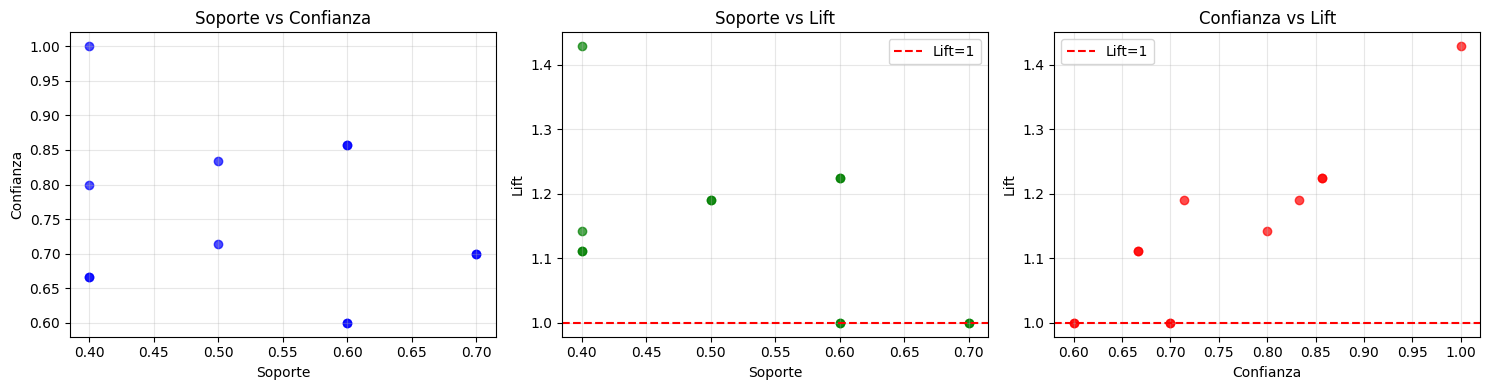

In [7]:
# Instalar matplotlib para visualización
!pip install matplotlib -q

import matplotlib.pyplot as plt

if not df_rules.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Gráfico de soporte vs confianza
    axes[0].scatter(df_rules['support'], df_rules['confidence'], alpha=0.7, c='blue')
    axes[0].set_xlabel('Soporte')
    axes[0].set_ylabel('Confianza')
    axes[0].set_title('Soporte vs Confianza')
    axes[0].grid(True, alpha=0.3)

    # Gráfico de soporte vs lift
    axes[1].scatter(df_rules['support'], df_rules['lift'], alpha=0.7, c='green')
    axes[1].set_xlabel('Soporte')
    axes[1].set_ylabel('Lift')
    axes[1].set_title('Soporte vs Lift')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=1, color='red', linestyle='--', label='Lift=1')
    axes[1].legend()

    # Gráfico de confianza vs lift
    axes[2].scatter(df_rules['confidence'], df_rules['lift'], alpha=0.7, c='red')
    axes[2].set_xlabel('Confianza')
    axes[2].set_ylabel('Lift')
    axes[2].set_title('Confianza vs Lift')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=1, color='red', linestyle='--', label='Lift=1')
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No hay suficientes reglas para generar gráficos.")

## 🔍 Interpretación de los resultados

### ¿Qué significan las métricas?

1. **Soporte (Support)**:
   - Indica la frecuencia con la que aparece un itemset en la base de datos.
   - Ejemplo: Support = 0.4 significa que el itemset aparece en el 40% de las transacciones.

2. **Confianza (Confidence)**:
   - Probabilidad de que el consecuente aparezca dado el antecedente.
   - Ejemplo: Confianza = 0.75 significa que en el 75% de los casos, si aparece el antecedente, también aparece el consecuente.

3. **Lift**:
   - Mide qué tan más probable es que el consecuente ocurra cuando ocurre el antecedente.
   - Lift > 1: correlación positiva (los ítems tienden a aparecer juntos)
   - Lift = 1: independencia
   - Lift < 1: correlación negativa

### Reglas encontradas en este ejemplo:

- Las reglas con mayor soporte indican combinaciones de productos que se compran juntos con frecuencia.
- Las reglas con alto lift indican asociaciones fuertes y no triviales.
- Estas reglas pueden utilizarse para:
  - Recomendación de productos (cross-selling)
  - Optimización de disposición en tiendas
  - Promociones y ofertas combinadas